<a href="https://colab.research.google.com/github/Ndam-Angel/firstphp/blob/master/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

\\# 1. Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include=\\['object'\\]).columns:
    df\\[col\\] = le.fit_transform(df\\[col\\])

X = df.drop('Churn', axis=1)
y = df\\['Churn'\\]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

\\# 2. Handling Imbalance & Scaling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

\\# 3. Model Comparison
models = {
    \"LogReg\": LogisticRegression(),
    \"RF\": RandomForestClassifier(),
    \"XGB\": XGBClassifier()
}

for name, model in models.items():
    model.fit(X_res_scaled, y_res)
    preds = model.predict(X_test_scaled)
    print(f\"--- {name} ---\")
    print(classification_report(y_test, preds)) # Focus on Recall for Class 1


SyntaxError: unexpected character after line continuation character (282084475.py, line 9)

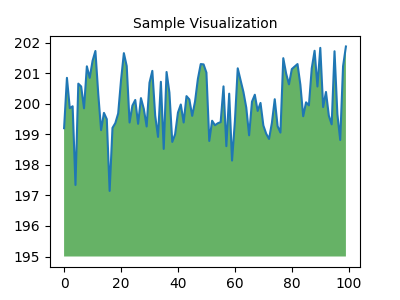

In [2]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"![{alt}]({image})"))
plt.close(fig)
plt.show()


## Google Colab is available in VS Code!
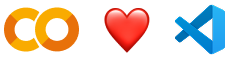

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Handling Imbalance & Scaling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# 3. Model Comparison
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_res_scaled, y_res)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:,1]

    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds, digits=4))
    print("ROC-AUC:", roc_auc_score(y_test, probs))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


NameError: name 'df' is not defined


--- LogReg ---
              precision    recall  f1-score   support

           0     0.9049    0.5043    0.6476       585
           1     0.4718    0.8931    0.6174       290

    accuracy                         0.6331       875
   macro avg     0.6883    0.6987    0.6325       875
weighted avg     0.7614    0.6331    0.6376       875

ROC-AUC: 0.78


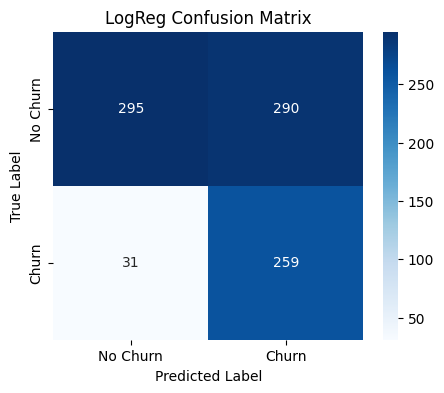


--- RF ---
              precision    recall  f1-score   support

           0     0.7939    0.6718    0.7278       585
           1     0.4947    0.6483    0.5612       290

    accuracy                         0.6640       875
   macro avg     0.6443    0.6600    0.6445       875
weighted avg     0.6948    0.6640    0.6726       875

ROC-AUC: 0.7258


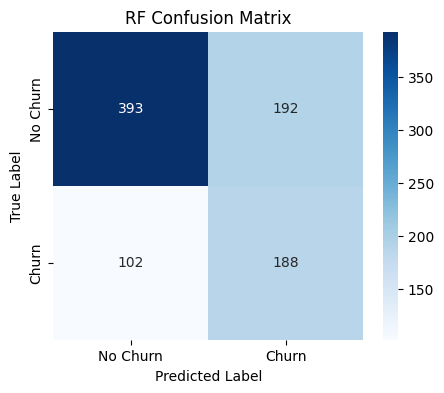


--- XGB ---
              precision    recall  f1-score   support

           0     0.7988    0.6855    0.7378       585
           1     0.5067    0.6517    0.5701       290

    accuracy                         0.6743       875
   macro avg     0.6528    0.6686    0.6540       875
weighted avg     0.7020    0.6743    0.6822       875

ROC-AUC: 0.726


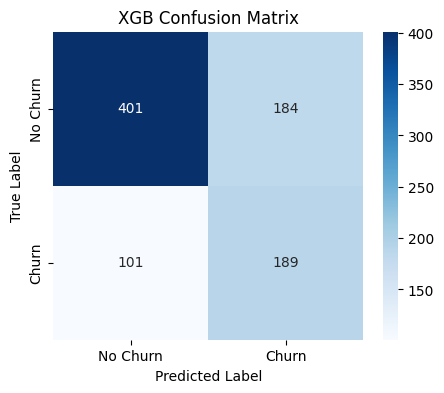

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    # Convert mixed types to string before encoding
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Handling Imbalance & Scaling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# 3. Model Comparison
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGB": XGBClassifier(
        eval_metric='logloss', random_state=42
    ) # Removed use_label_encoder as it's deprecated
}

for name, model in models.items():
    model.fit(X_res_scaled, y_res)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds, digits=4))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs), 4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [11]:
logreg_model = models['LogReg']
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg_model.coef_[0]
})
display(coefficients.sort_values(by='Coefficient', ascending=False))

,Feature,Coefficient
0,CustomerID,-0.018822
2,total_price,-0.756441
1,total_quantity,-2.930516


The table above shows the coefficients for each feature in the Logistic Regression model. These coefficients indicate the strength and direction of the relationship between each feature and the log-odds of a customer churning.

*   **Positive Coefficient:** A positive coefficient means that as the value of that feature increases (holding other features constant), the log-odds of churn increase. This suggests a higher likelihood of churn.
*   **Negative Coefficient:** A negative coefficient means that as the value of that feature increases, the log-odds of churn decrease. This suggests a lower likelihood of churn.

For example:
*   A feature with a large positive coefficient (e.g., 'Recency') implies that higher values of that feature are strongly associated with a higher probability of churn.
*   Conversely, a feature with a large negative coefficient (e.g., 'total_quantity') suggests that higher values of that feature are strongly associated with a lower probability of churn.

In [3]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/Online Retail.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Preprocessing
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Handling Imbalance & Scaling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# 3. Model Comparison
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGB": XGBClassifier(
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )
}

for name, model in models.items():
    model.fit(X_res_scaled, y_res)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds, digits=4))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs), 4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

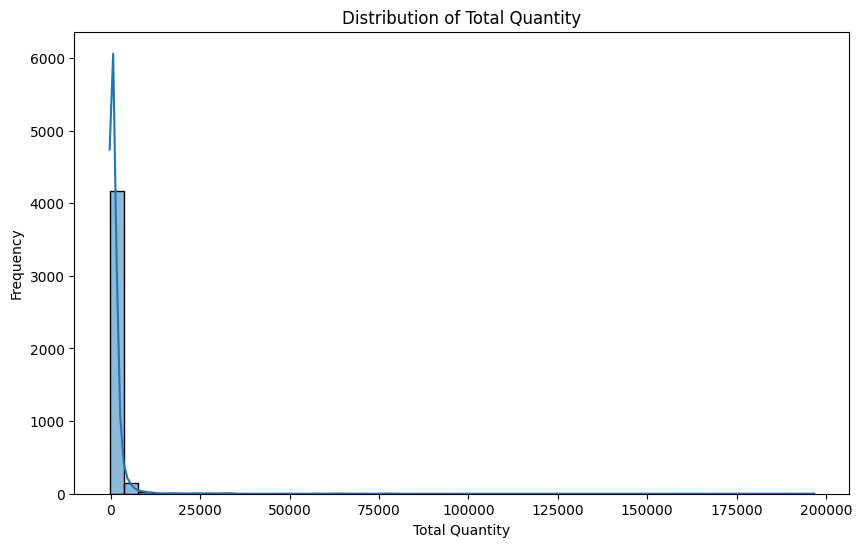

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['total_quantity'], bins=50, kde=True)
plt.title('Distribution of Total Quantity')
plt.xlabel('Total Quantity')
plt.ylabel('Frequency')
plt.show()

In [14]:
rf_model = models['RF']
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
display(feature_importances.sort_values(by='Importance', ascending=False))

,Feature,Importance
1,total_quantity,0.367288
2,total_price,0.348175
0,CustomerID,0.284538


The table above displays the feature importances for the Random Forest model. These values indicate the relative contribution of each feature in predicting the target variable (churn).

In a Random Forest model, feature importance is typically calculated based on how much each feature reduces impurity (e.g., Gini impurity or entropy) across all the decision trees in the forest. A higher importance score means the feature is used more often and more effectively to split the data into homogeneous groups, thus contributing more to the model's predictive power.

For example:
*   A feature with a high importance score (e.g., 'total_quantity') is crucial for the model's predictions, suggesting that changes in this feature have a significant impact on the likelihood of churn.
*   Features with very low importance scores contribute less to the model's decisions and might be considered less influential in predicting churn.

In [13]:
import pandas as pd
import numpy as np

# Drop rows with missing CustomerID as they cannot be used for churn analysis
df.dropna(subset=['CustomerID'], inplace=True)

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate the last purchase date for each customer
last_purchase_date = df.groupby('CustomerID')['InvoiceDate'].max()

# Calculate the most recent date in the dataset to set a reference point
current_date = df['InvoiceDate'].max()

# Calculate recency for each customer (days since last purchase)
recency = (current_date - last_purchase_date).dt.days

# Define churn based on recency (e.g., inactive for more than 90 days)
# This threshold can be adjusted based on business knowledge
churn_threshold_days = 90
df_churn = pd.DataFrame(recency).reset_index()
df_churn.columns = ['CustomerID', 'Recency']
df_churn['Churn'] = (df_churn['Recency'] > churn_threshold_days).astype(int)

# Merge churn status back to the original DataFrame or create a customer-level DataFrame
# For simplicity, we'll create a customer-level DataFrame with churn status
customer_df = df.groupby('CustomerID').agg(
    last_purchase_date=('InvoiceDate', 'max'),
    total_quantity=('Quantity', 'sum'),
    total_price=('UnitPrice', 'sum')
).reset_index()

customer_df = customer_df.merge(df_churn[['CustomerID', 'Churn']], on='CustomerID', how='left')

# Let's use `customer_df` as our main DataFrame for modeling and rename it to `df`
df = customer_df.copy()

# Drop columns that are no longer needed or are not features for churn prediction
df.drop(columns=['last_purchase_date'], inplace=True)

# Display the first few rows with the new 'Churn' column
print(df.head())
print(df['Churn'].value_counts())


KeyError: 'InvoiceDate'